https://github.com/hwantajee
## 의사결정트리

In [1]:
from sklearn.datasets import load_iris

In [2]:
iris = load_iris()
data = iris.data
label = iris.target

In [3]:
import matplotlib.pyplot as plt
import numpy as np

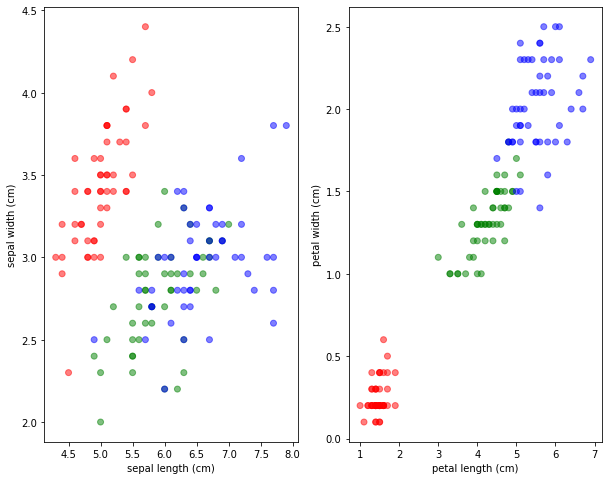

In [4]:
fig = plt.figure(figsize=(10, 8))
ax1 = fig.add_subplot(1, 2, 1)
colors = np.array(["red", "green", "blue"])
names = iris.feature_names
ax1.scatter(data[:, 0], data[:, 1], color=colors[label], alpha=0.5)
ax1.set_xlabel(names[0])
ax1.set_ylabel(names[1])

ax2 = fig.add_subplot(1, 2, 2)
ax2.scatter(data[:, 2], data[:, 3], color=colors[label], alpha=0.5)
ax2.set_xlabel(names[2])
ax2.set_ylabel(names[3])
plt.show()

In [5]:
data = data[:, [2, 3]]
print(data.shape)
print(label.shape)

(150, 2)
(150,)


In [6]:
from sklearn.model_selection import train_test_split

In [7]:
train_data, test_data, train_label, test_label = train_test_split(data, label, test_size=0.3, random_state=1)

#### 표준화

In [8]:
from sklearn.preprocessing import StandardScaler

In [9]:
sc = StandardScaler()

# fit()은 분석할 때 사용하지만 여기서는 작업형 함수로 사용됨
sc.fit(train_data)            
sc.fit(test_data)

# 데이터 정규화 자동화
train_data_std = sc.transform(train_data)       
test_data_std = sc.transform(test_data) 

print(train_data_std)

[[ 1.81112954  1.51820153]
 [-1.23125605 -1.29328278]
 [-1.40677829 -1.433857  ]
 [-1.40677829 -1.29328278]
 [ 0.05590709  0.25303359]
 [-1.34827088 -1.433857  ]
 [-1.46528571 -1.433857  ]
 [ 1.69411471  1.37762731]
 [ 0.93351831  1.2370531 ]
 [ 1.46008505  0.81533045]
 [ 1.05053314  1.37762731]
 [ 0.58247382  0.81533045]
 [ 0.40695158  0.53418202]
 [ 1.69411471  1.09647888]
 [ 0.23142933 -0.02811484]
 [-1.28976346 -1.433857  ]
 [ 0.69948865  1.09647888]
 [ 0.64098124  0.81533045]
 [-1.40677829 -1.57443122]
 [-1.46528571 -1.433857  ]
 [ 1.16754797  1.37762731]
 [-1.40677829 -1.29328278]
 [ 0.64098124  0.81533045]
 [ 0.75799607  1.09647888]
 [ 0.34844416  0.25303359]
 [ 0.40695158  0.11245937]
 [ 1.10904056  1.79934996]
 [ 0.58247382  0.81533045]
 [-1.28976346 -1.433857  ]
 [ 0.1144145  -0.30926327]
 [ 0.28993675  0.11245937]
 [ 0.99202573  0.81533045]
 [-0.29513741 -0.30926327]
 [ 1.2845628   1.79934996]
 [ 0.1144145   0.11245937]
 [-1.34827088 -1.433857  ]
 [-1.34827088 -1.433857  ]
 

In [10]:
from sklearn.tree import DecisionTreeClassifier

In [11]:
dtc = DecisionTreeClassifier(criterion = "entropy", max_depth=3, random_state=1)
model = dtc.fit(train_data, train_label)

print(model.score(train_data, train_label))
print(model.score(test_data, test_label))

0.9809523809523809
0.9555555555555556


In [12]:
from pydotplus import graph_from_dot_data
from sklearn.tree import export_graphviz
from IPython.display import Image

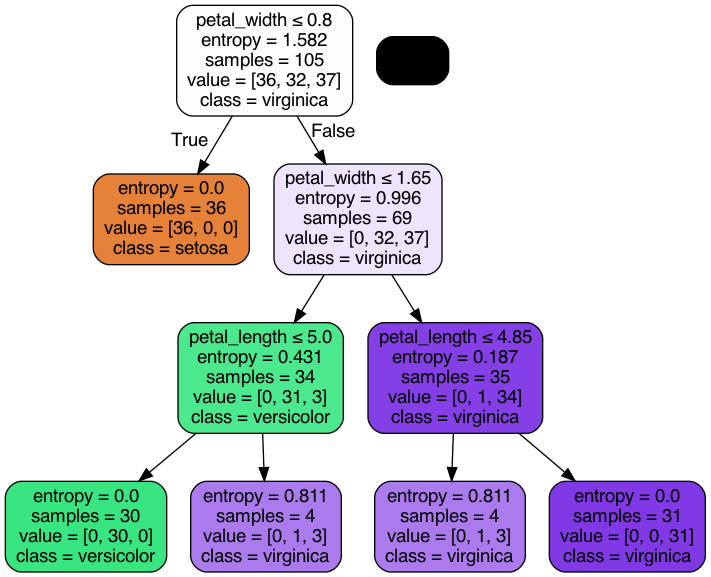

In [17]:
dot_data = export_graphviz(dtc, feature_names=["petal_length", "petal_width"], \
                           class_names = iris.target_names, filled=True, rounded=True, special_characters=True)
graph = graph_from_dot_data(dot_data)
# graph.write_png("iris.png")
Image("./iris.png")